In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#data=pd.read_csv('train.csv')

In [3]:
import warnings
warnings.simplefilter('ignore')

In [17]:
data=pd.read_csv('train.csv')

In [18]:
#data.info()
data.isnull().sum()

Unnamed: 0                            0
hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             374
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             13061


In [52]:
data.country.value_counts()

country
PRT    38760
GBR     9675
FRA     8382
ESP     6861
DEU     5850
       ...  
MWI        1
BWA        1
NCL        1
MDG        1
CYM        1
Name: count, Length: 174, dtype: int64

In [19]:
data.columns

Index(['Unnamed: 0', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [20]:
data2=data.copy()
data2.drop(columns=['Unnamed: 0','arrival_date_year','arrival_date_week_number','arrival_date_day_of_month','country','assigned_room_type','agent','company','name','email','phone-number', 'credit_card','reservation_status','reservation_status_date','country'], inplace=True)

In [21]:
#data2.shape#23
data.shape#37
len(data2.columns)
#print(data2.shape)

23

In [24]:
duplicates = data2[data2.duplicated()]
duplicates

,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests


In [23]:
data2.drop_duplicates(inplace=True)

In [12]:
data2.shape

(68600, 23)

In [53]:
#cols_with_negatives = data2.columns[(data2 < 0).any()].tolist()
numeric_df = data2.select_dtypes(include='number')
negative_cols = (numeric_df < 0).any()
print(negative_cols)

is_canceled                       False
lead_time                         False
stays_in_weekend_nights           False
stays_in_week_nights              False
adults                            False
children                          False
babies                            False
is_repeated_guest                 False
previous_cancellations            False
previous_bookings_not_canceled    False
booking_changes                   False
days_in_waiting_list              False
adr                                True
required_car_parking_spaces       False
total_of_special_requests         False
dtype: bool


In [27]:
data2.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_month                0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          4
babies                            0
meal                              0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

In [28]:
data.arrival_date_year.value_counts()
df_2017=data[data['arrival_date_year']==2017]

In [29]:
df_2017.drop(columns=['Unnamed: 0','arrival_date_week_number','arrival_date_year',
       'arrival_date_day_of_month','name','email','phone-number', 'credit_card','reservation_status_date','country'], inplace=True)

In [30]:
df_2017.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32550 entries, 0 to 95508
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           32550 non-null  object 
 1   is_canceled                     32550 non-null  int64  
 2   lead_time                       32550 non-null  int64  
 3   arrival_date_month              32550 non-null  object 
 4   stays_in_weekend_nights         32550 non-null  int64  
 5   stays_in_week_nights            32550 non-null  int64  
 6   adults                          32550 non-null  int64  
 7   children                        32550 non-null  float64
 8   babies                          32550 non-null  int64  
 9   meal                            32550 non-null  object 
 10  market_segment                  32550 non-null  object 
 11  distribution_channel            32550 non-null  object 
 12  is_repeated_guest               32550

In [31]:
df_2017.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status'],
      dtype='object')

In [32]:
df_2017.shape

(32550, 27)

In [33]:
df_2017.is_canceled.value_counts()
#0==no cancellation, record=19996, 1==cancellation, 12554

is_canceled
0    19996
1    12554
Name: count, dtype: int64

In [22]:
df_2017.arrival_date_month.value_counts()

arrival_date_month
May         5061
April       4509
June        4490
July        4256
March       4017
August      3955
February    3310
January     2952
Name: count, dtype: int64

In [23]:
df_2017.booking_changes.value_counts()

booking_changes
0     27434
1      3386
2      1222
3       300
4       129
5        34
6        23
7         8
8         4
10        3
14        2
11        1
18        1
15        1
16        1
13        1
Name: count, dtype: int64

In [24]:
df_2017.deposit_type.value_counts()

deposit_type
No Deposit    29251
Non Refund     3276
Refundable       23
Name: count, dtype: int64

In [14]:
df_2017.agent.value_counts()

agent
9.0      10659
240.0     3945
14.0      1314
7.0       1153
250.0      926
         ...  
281.0        1
299.0        1
476.0        1
71.0         1
461.0        1
Name: count, Length: 183, dtype: int64

In [15]:
df_2017.company.value_counts()

company
223.0    178
40.0     151
153.0     91
67.0      76
169.0     55
        ... 
459.0      1
448.0      1
250.0      1
497.0      1
243.0      1
Name: count, Length: 185, dtype: int64

In [16]:
df_2017.adr.value_counts()
# tariff of room

adr
90.00     836
80.00     668
75.00     627
95.00     559
120.00    532
         ... 
55.35       1
166.71      1
195.25      1
93.13       1
90.74       1
Name: count, Length: 3879, dtype: int64

In [17]:
df_2017.customer_type.value_counts()

customer_type
Transient          27043
Transient-Party     4817
Contract             520
Group                170
Name: count, dtype: int64

In [18]:
df_2017.adults.value_counts()
#24411=2 adults, 5907= adults, 2106= 3 adults, 

adults
2    24411
1     5907
3     2106
0      109
4       17
Name: count, dtype: int64

In [19]:
df_2017.children.value_counts()
#29701=0 Children, 1596= 1 children, 1226= 2 children, 

children
0.0    29701
1.0     1596
2.0     1226
3.0       27
Name: count, dtype: int64

In [20]:
df_2017.babies.value_counts()
#32340=0 Babies, 206= 1 baby, 4= 2 babies

babies
0    32340
1      206
2        4
Name: count, dtype: int64

In [21]:
df_2017.stays_in_weekend_nights.value_counts()
#13482=0 day booking_on_weekend , 9731= 1 day booking_on_weekend, 8364= 2 day booking_on_weekend 

stays_in_weekend_nights
0     13482
2      9731
1      8364
4       529
3       332
6        67
8        22
5        12
10        5
16        2
13        1
7         1
12        1
9         1
Name: count, dtype: int64

In [22]:
df_2017.stays_in_week_nights.value_counts()
#8476=2 day booking_on_week , 7858= 1 day booking_on_week, 6708= 3 day booking_on_week, 

stays_in_week_nights
2     8476
1     7858
3     6708
5     3329
4     2865
0     1961
6      396
7      282
10     272
8      194
9       66
15      30
19      27
14      17
12      15
20      12
11      12
16       7
13       6
21       5
22       4
25       3
40       2
30       1
17       1
26       1
Name: count, dtype: int64

In [23]:
df_2017.meal.value_counts()
#24406=having meal of BED_Breakfast , 4145= having meal of Self Catering, 3598= having meal of DINNER_Breakfast, 

meal
BB           24406
SC            4145
HB            3598
Undefined      327
FB              74
Name: count, dtype: int64

In [24]:
df_2017.required_car_parking_spaces.value_counts()
#30825=Parking Space is not needed , 1713= Need one parking space

required_car_parking_spaces
0    30825
1     1713
2        9
8        2
3        1
Name: count, dtype: int64

In [25]:
df_2017.reserved_room_type.value_counts()
#22005=Room with attach toilet(Average), 6109= Big Room with attach toilet(Deluxe)
#2174= Elegant Room with attach toilet(Elegant)

reserved_room_type
A    22005
D     6109
E     2174
F      892
G      670
C      377
B      162
H      156
P        5
Name: count, dtype: int64

In [26]:
df_2017.arrival_date_month.value_counts()

arrival_date_month
May         5061
April       4509
June        4490
July        4256
March       4017
August      3955
February    3310
January     2952
Name: count, dtype: int64

In [27]:
df_2017.market_segment.value_counts()

market_segment
Online TA        18211
Groups            4648
Offline TA/TO     4528
Direct            3674
Corporate         1225
Complementary      172
Aviation            92
Name: count, dtype: int64

In [28]:
df_2017.is_repeated_guest.value_counts()
#31455==Fresh Guest, 1095==Repeated guest

is_repeated_guest
0    31455
1     1095
Name: count, dtype: int64

In [29]:
df_2017.previous_cancellations.value_counts()
#32328==0 cancellation, 152==1 time cancellaion

previous_cancellations
0    32328
1      152
2       29
4       18
6       14
3        5
5        4
Name: count, dtype: int64

In [1]:
df_2017.previous_bookings_not_canceled.value_counts()
#31418==0 cancellation, 

NameError: name 'df_2017' is not defined

In [31]:
df_2017.lead_time.value_counts()

lead_time
0      1443
1       800
2       504
3       418
4       414
       ... 
366       1
387       1
390       1
389       1
458       1
Name: count, Length: 427, dtype: int64

In [32]:
df_2017.reservation_status.value_counts() # Imabalanced data
# 19906==check_out, 12268==Cancealed, 286==No show

reservation_status
Check-Out    19996
Canceled     12268
No-Show        286
Name: count, dtype: int64

In [43]:
df_2017 = df_2017[df_2017['reservation_status'].isin(['Canceled', 'Check-Out'])]


In [25]:
df_2017.columns

Index(['Unnamed: 0', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [46]:
df_2017.shape

(32264, 27)

In [34]:
cat_cols=['hotel','is_canceled','arrival_date_month','meal',
        'market_segment', 'distribution_channel','is_repeated_guest','reserved_room_type',
       'assigned_room_type', 'deposit_type', 'customer_type','required_car_parking_spaces','reservation_status']

In [35]:
len(cat_cols)

13

In [36]:
num_cols=['lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies','previous_cancellations',
       'previous_bookings_not_canceled','booking_changes','agent',
       'company', 'days_in_waiting_list', 'adr',
       'total_of_special_requests'
        ]

In [37]:
#len(cat_cols)#13
len(num_cols)#14

14

In [39]:
df_2017.head()

,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,City Hotel,1,64,May,2,1,3,0.0,0,BB,...,0,No Deposit,9.0,NaN,0,Transient,189.00,0,0,Canceled
1,City Hotel,0,34,July,1,1,2,1.0,0,BB,...,0,No Deposit,14.0,NaN,0,Transient,146.00,0,0,Check-Out
3,Resort Hotel,1,251,May,2,4,2,0.0,0,BB,...,0,No Deposit,NaN,NaN,0,Transient,89.70,0,1,Canceled
4,Resort Hotel,0,23,February,1,1,2,0.0,0,BB,...,0,No Deposit,241.0,NaN,0,Transient,42.43,0,1,Check-Out
7,City Hotel,0,123,June,2,1,2,0.0,0,BB,...,0,No Deposit,9.0,NaN,0,Transient-Party,105.30,0,1,Check-Out


In [44]:
df1=df_2017.copy()
df1.columns
df1.shape

(32550, 27)

In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32550 entries, 0 to 95508
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           32550 non-null  object 
 1   is_canceled                     32550 non-null  int64  
 2   lead_time                       32550 non-null  int64  
 3   arrival_date_month              32550 non-null  object 
 4   stays_in_weekend_nights         32550 non-null  int64  
 5   stays_in_week_nights            32550 non-null  int64  
 6   adults                          32550 non-null  int64  
 7   children                        32550 non-null  float64
 8   babies                          32550 non-null  int64  
 9   meal                            32550 non-null  object 
 10  market_segment                  32550 non-null  object 
 11  distribution_channel            32550 non-null  object 
 12  is_repeated_guest               32550

In [42]:
# UNIVARIATE ANALYSIS

def num_features(df, num_features):
    fig, axes=plt.subplots(len(num_features),2,figsize=(15,len(num_features)*5))

    if len(num_features)==1:
        axes=[axes]
    for i ,colmn in enumerate(num_features):
        sns.histplot(data=df, x=colmn, ax=axes[i][0], kde=True, palette='Blues')
        axes[i][0].set_title(f"Histogram of {colmn}")

        sns.boxplot(data=df, x=colmn, ax=axes[i][1], palette='Blues')
        axes[i][1].set_title(f"BOXPLOT of {colmn}")

    plt.tight_layout()
    plt.show()




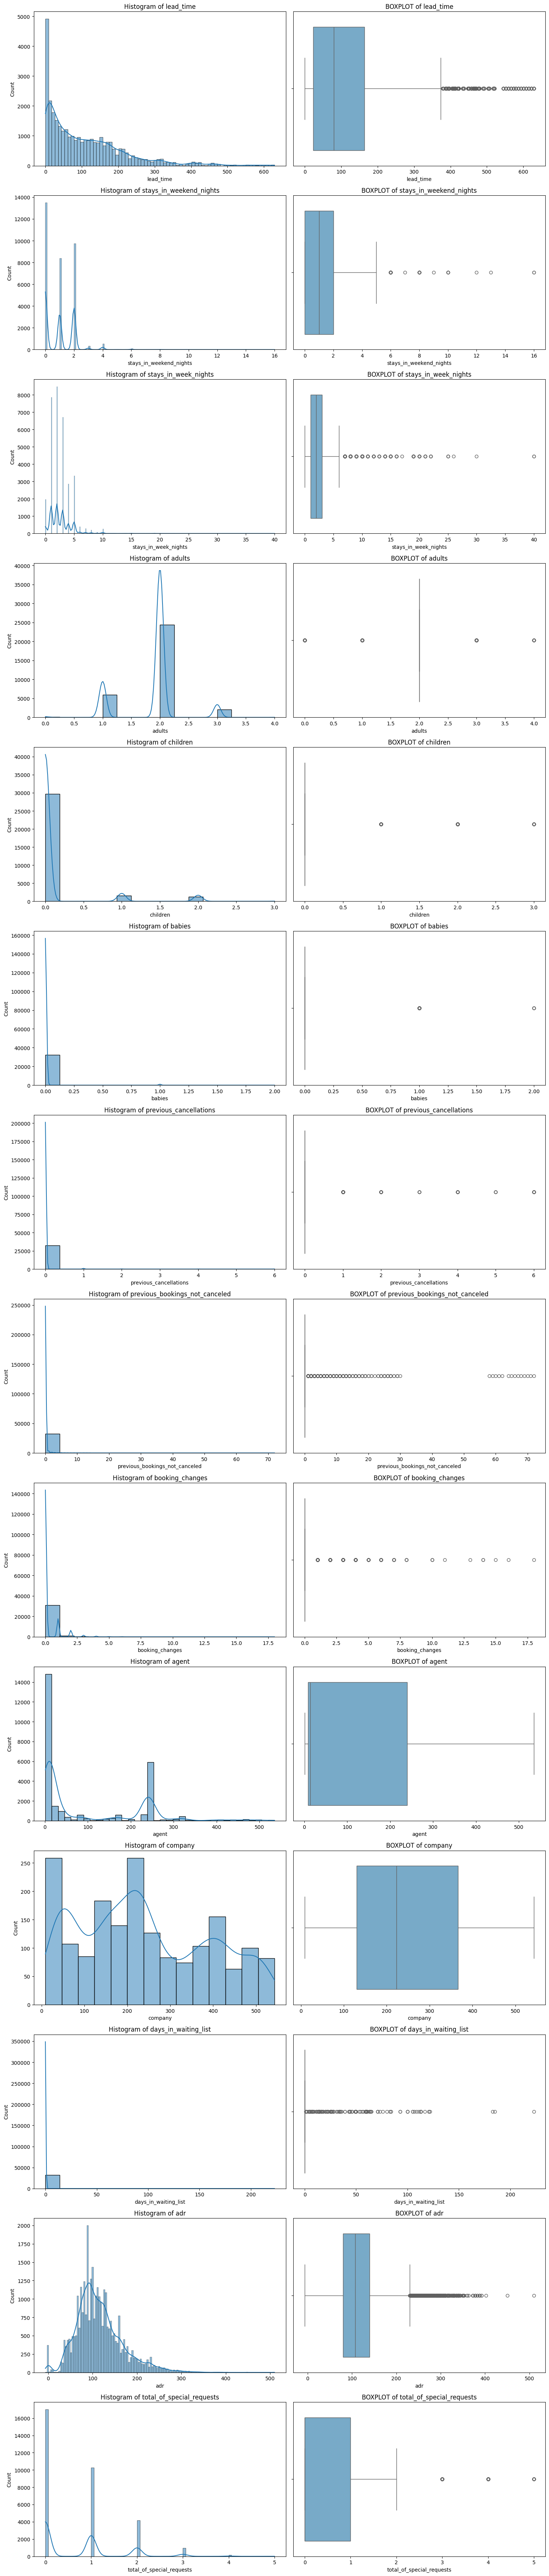

In [47]:
num_features(df1,num_cols)

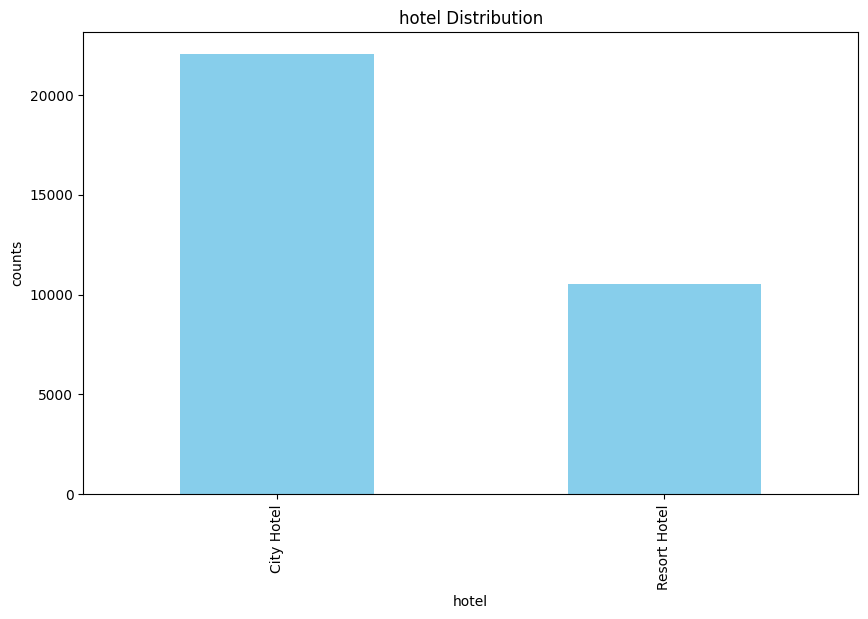

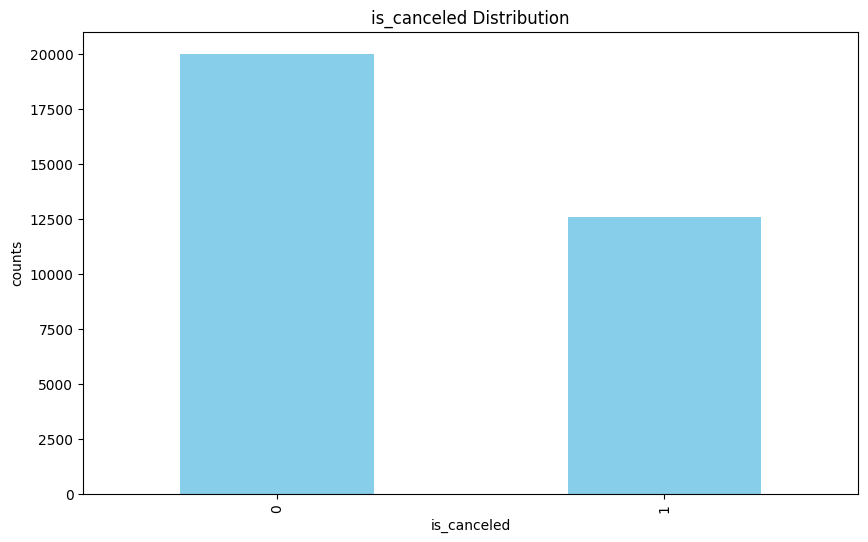

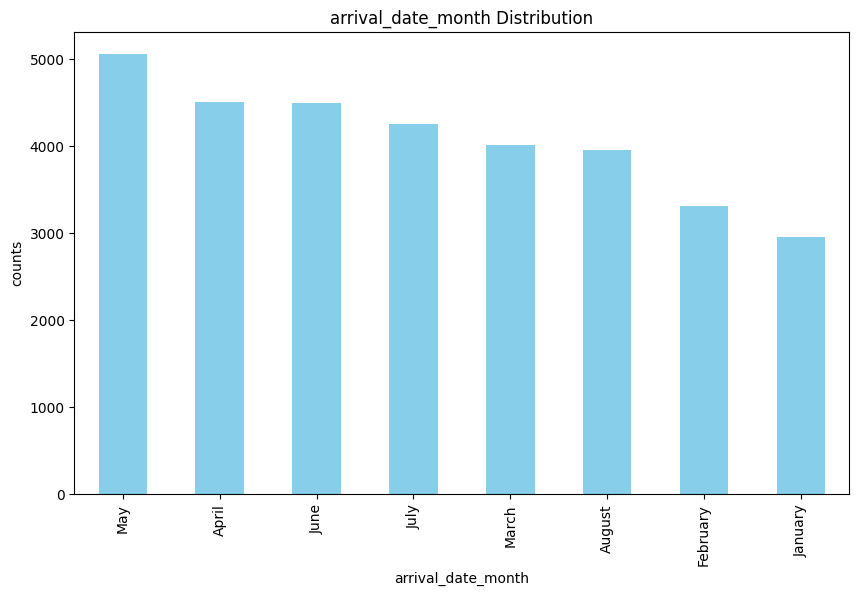

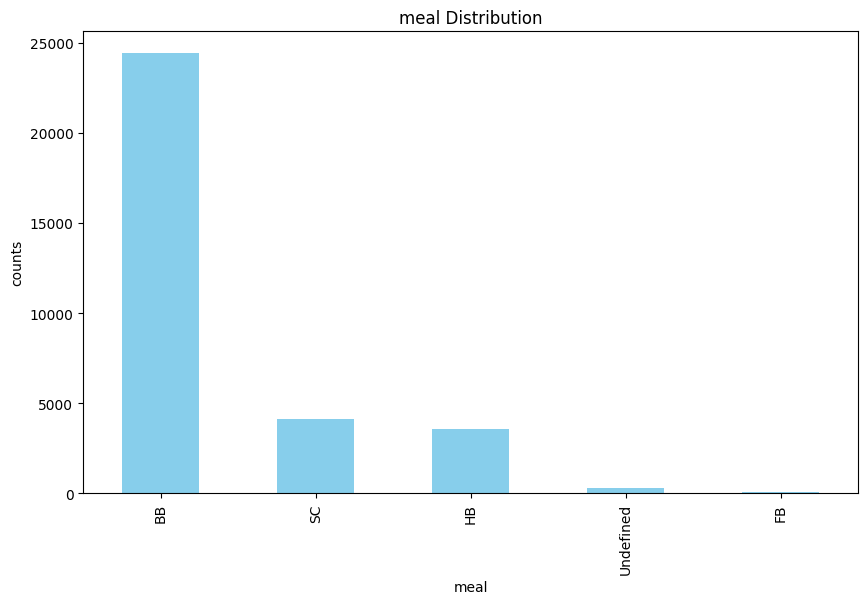

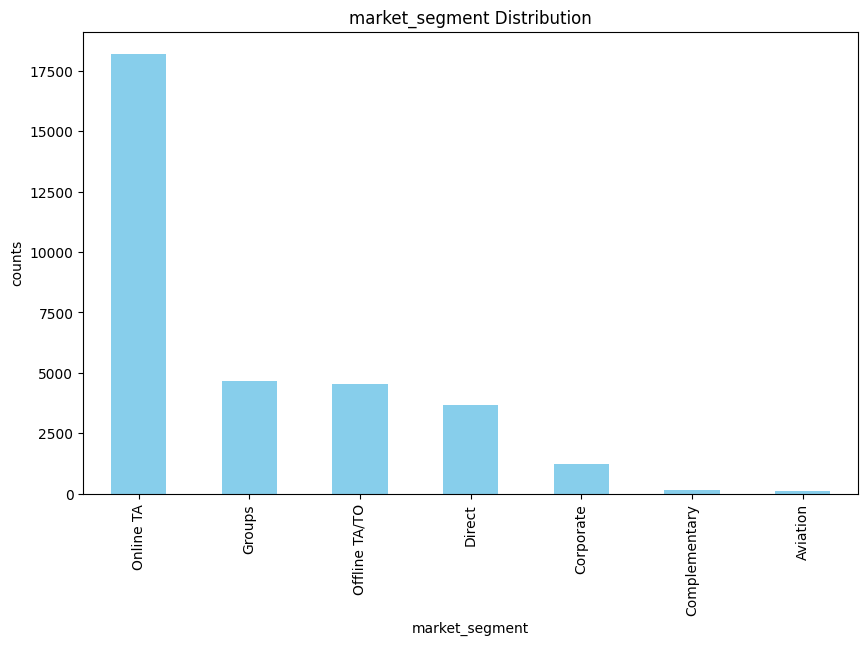

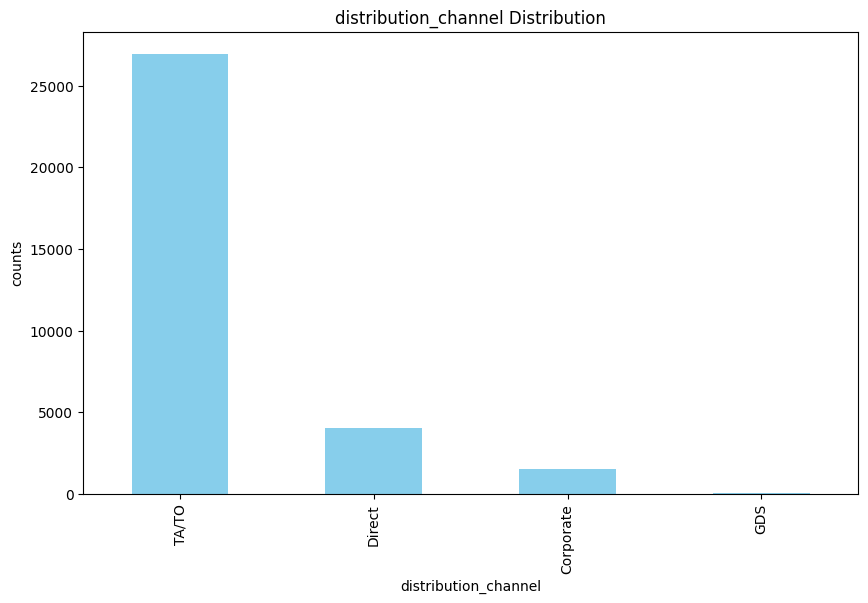

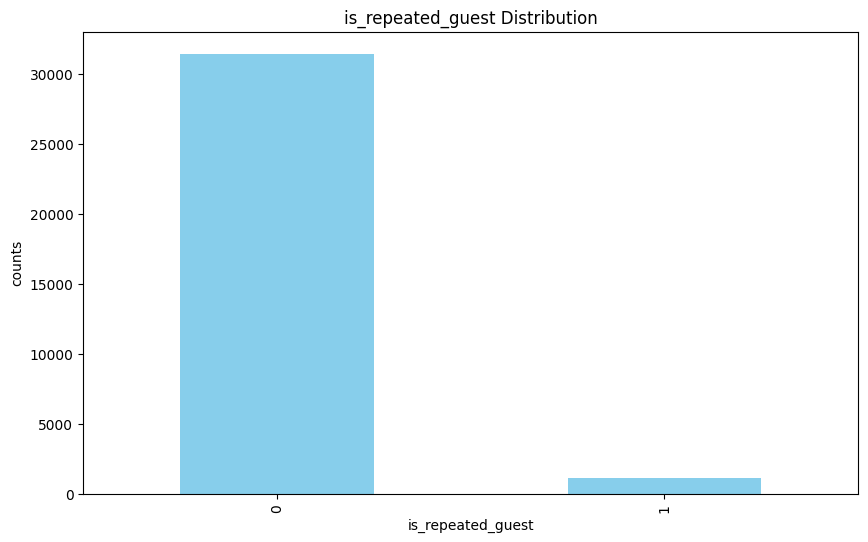

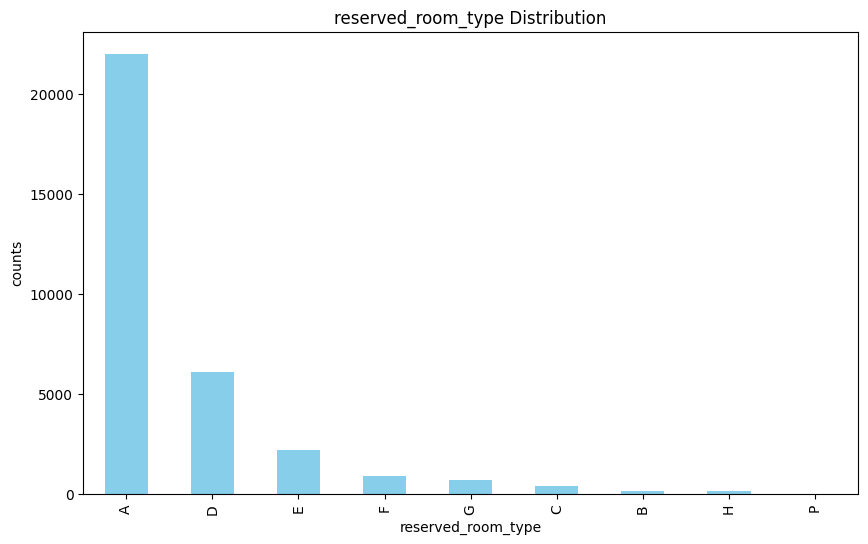

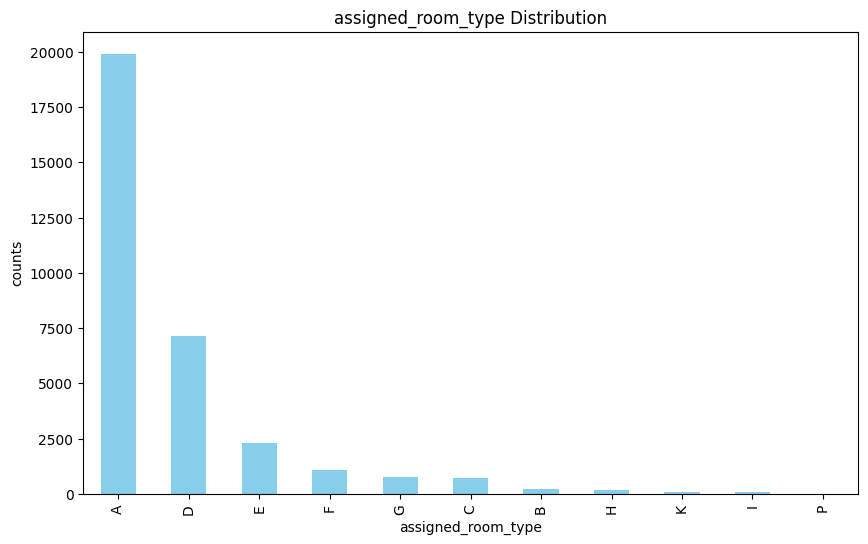

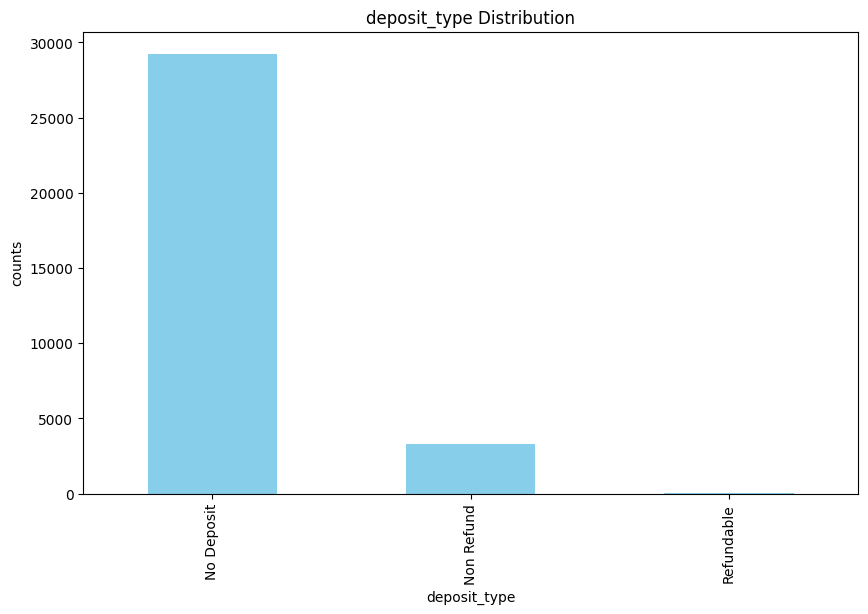

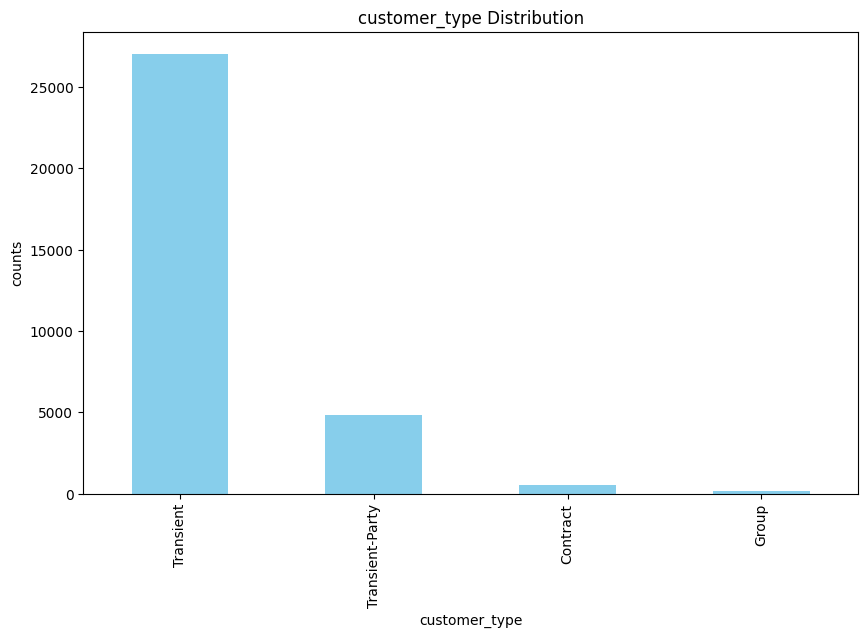

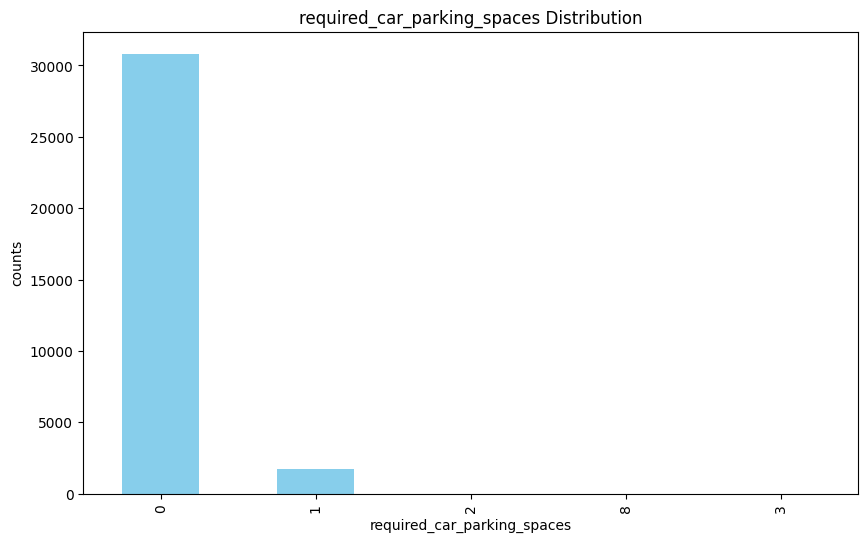

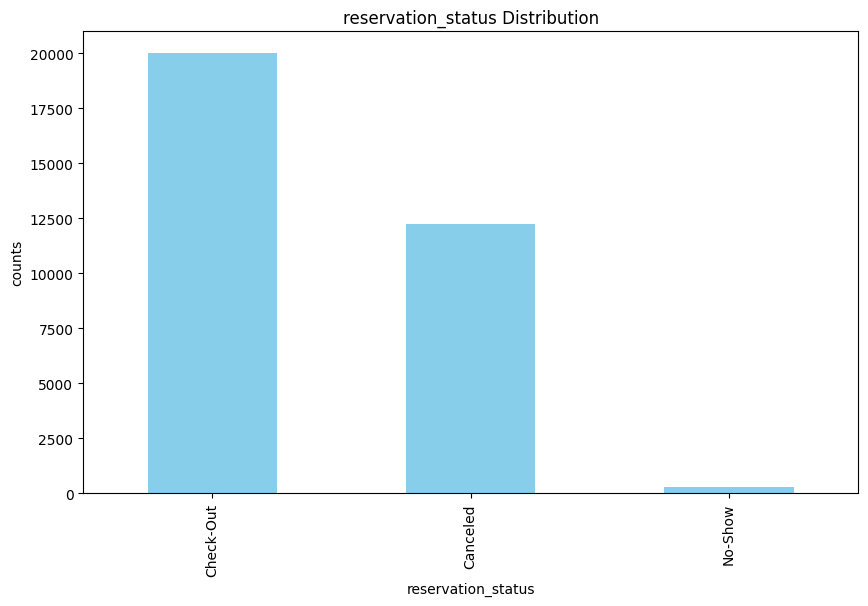

In [17]:
for cat_features in cat_cols:
    plt.figure(figsize=(10,6))
    df1[cat_features].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f"{cat_features} Distribution")
    plt.xlabel(cat_features)
    plt.ylabel('counts')
    plt.show()

In [19]:
#BIVARIATE ANALYSIS
def plot_bv(df,target,num_features):
    num_plots=len(num_features)
    num_rows=(num_plots+1)//2
    fig,axes=plt.subplots(num_rows,2,figsize=(15,num_rows*5))
    axes=axes.flatten()

    for i ,column in enumerate(num_features):
        sns.boxplot(x=target, y=column,ax=axes[i], data=df , palette='Blues')
        axes[i].set_title(f"{column} VS {target}")

    plt.tight_layout()
    plt.show()


In [49]:
df1.is_canceled.value_counts()

is_canceled
0    19996
1    12554
Name: count, dtype: int64

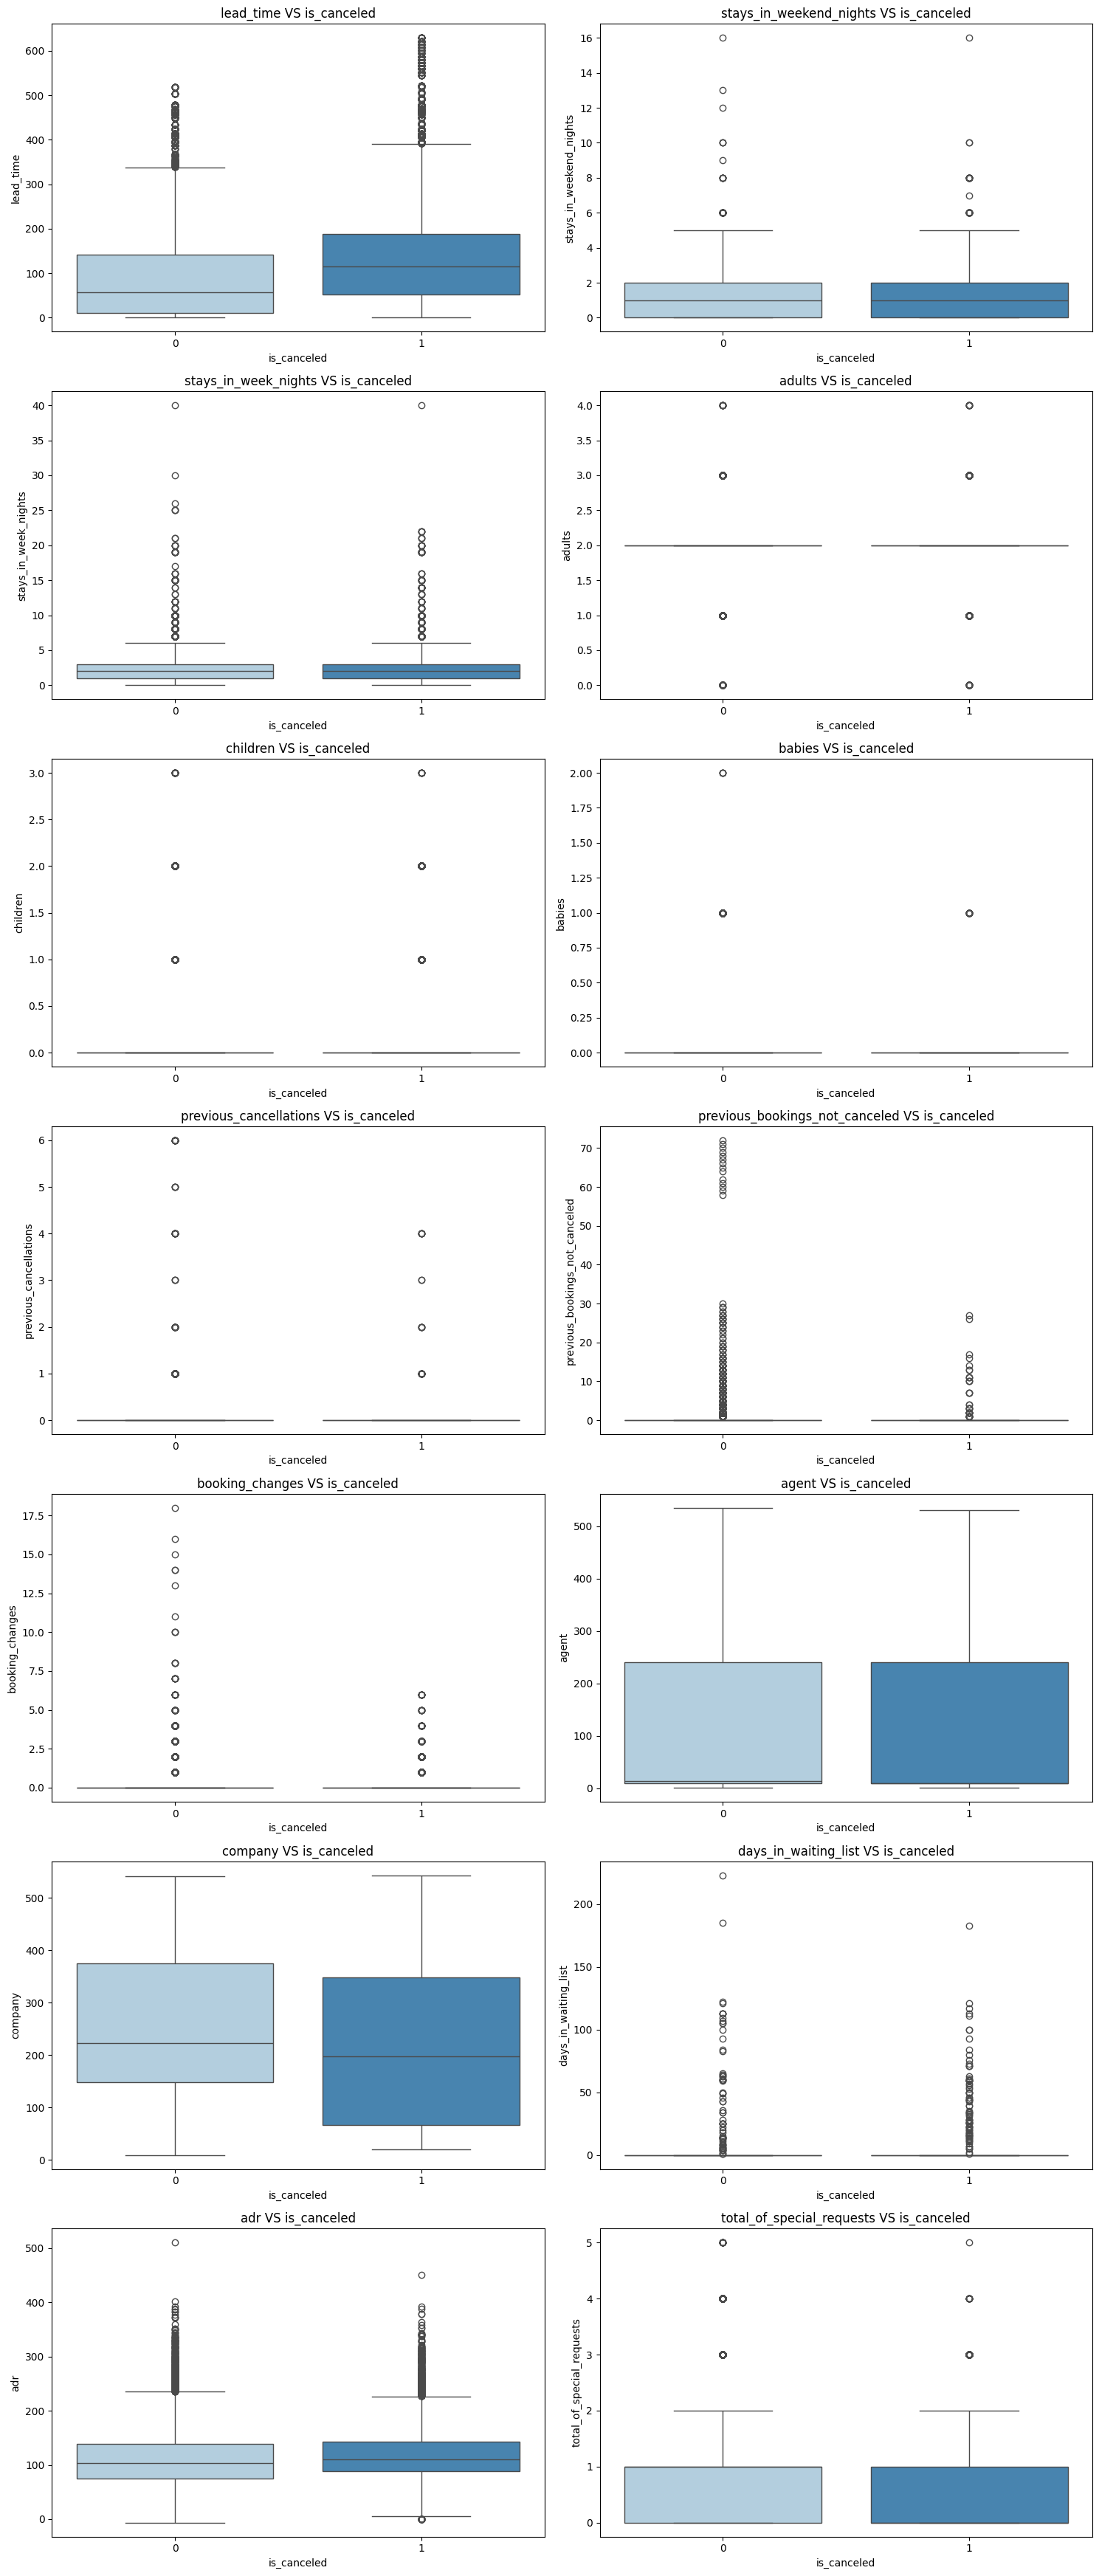

In [21]:
plot_bv(df1,'is_canceled', num_cols)

In [45]:
df1.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status'],
      dtype='object')

In [22]:
def plot_bv_cat(df,target,cat_features):
    num_plots=len(cat_features)
    num_rows=(num_plots+1)//2
    fig,axes=plt.subplots(num_rows,2,figsize=(15,num_rows*5))
    axes=axes.flatten()

    for i ,column in enumerate(cat_features):
        sns.countplot(x=column, hue=target,ax=axes[i], data=df , palette='Set2')
        axes[i].set_title(f"{column} VS {target}")

    plt.tight_layout()
    plt.show()


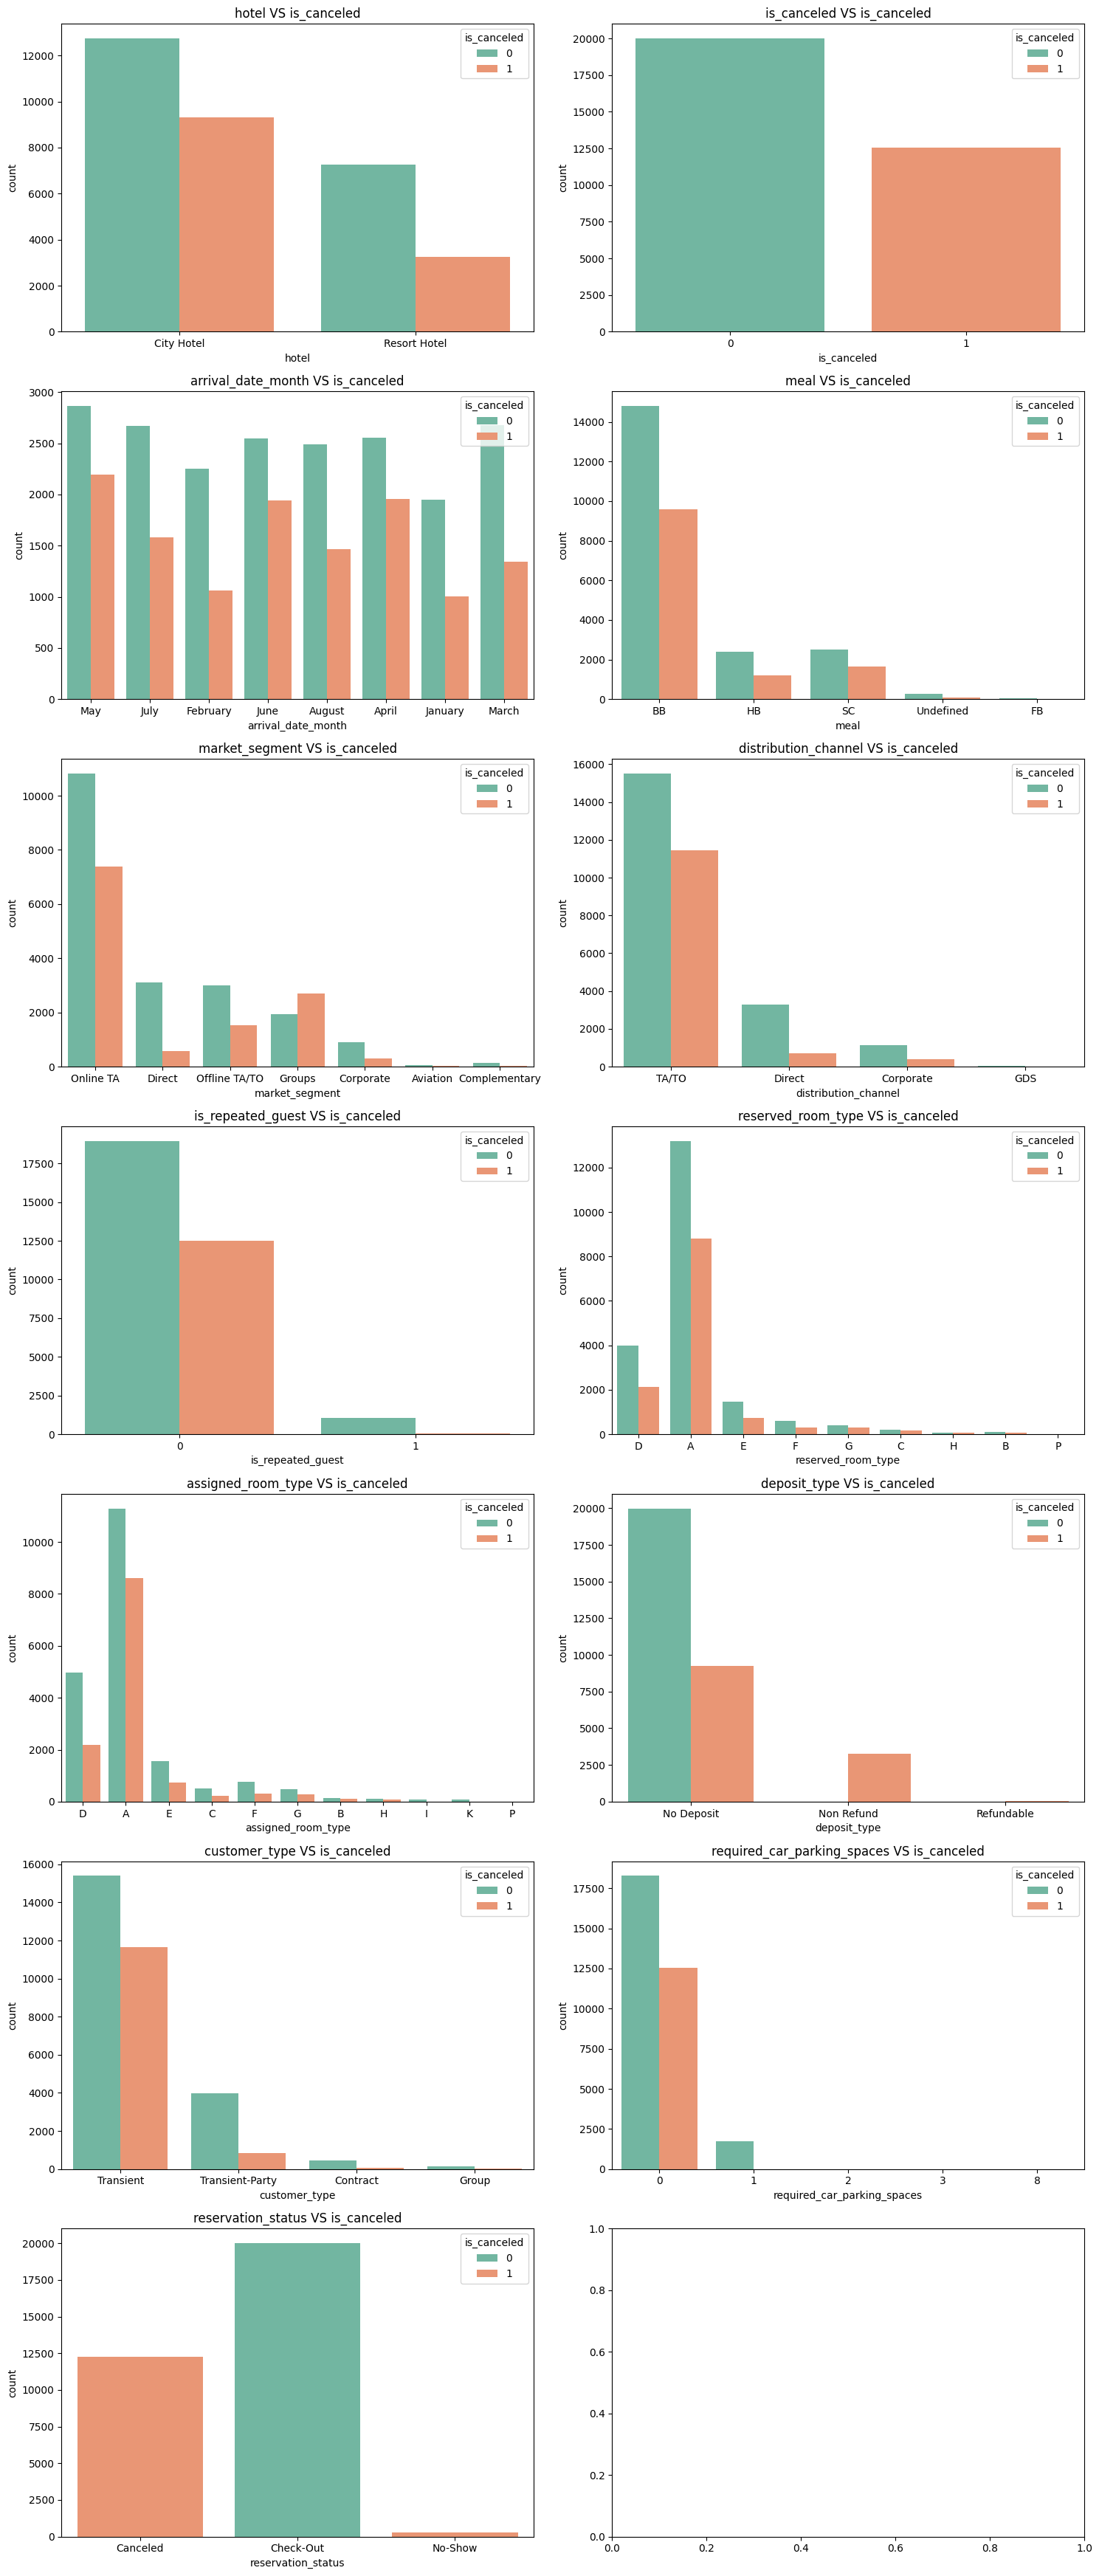

In [23]:
plot_bv_cat(df1,'is_canceled', cat_cols)

In [46]:
df1.shape

(32550, 27)

In [48]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
mappings={}
for col in cat_cols:
    df1[col]=le.fit_transform(df1[col])

    mappings[col]={label:code for label, code in zip(le.classes_,le.transform(le.classes_))}

logger.info(f"Mappings are ....")

for col, mapping in mappings.items():
    logger.info(f"{col} : {mapping}")

logger.info(f"Skewness Handling ....")

skew_threshold=self.config['data'][]

SyntaxError: invalid syntax (2280596347.py, line 16)

In [66]:
mappings

{'hotel': {'City Hotel': np.int64(0), 'Resort Hotel': np.int64(1)},
 'is_canceled': {np.int64(0): np.int64(0), np.int64(1): np.int64(1)},
 'arrival_date_month': {'April': np.int64(0),
  'August': np.int64(1),
  'February': np.int64(2),
  'January': np.int64(3),
  'July': np.int64(4),
  'June': np.int64(5),
  'March': np.int64(6),
  'May': np.int64(7)},
 'meal': {'BB': np.int64(0),
  'FB': np.int64(1),
  'HB': np.int64(2),
  'SC': np.int64(3),
  'Undefined': np.int64(4)},
 'market_segment': {'Aviation': np.int64(0),
  'Complementary': np.int64(1),
  'Corporate': np.int64(2),
  'Direct': np.int64(3),
  'Groups': np.int64(4),
  'Offline TA/TO': np.int64(5),
  'Online TA': np.int64(6)},
 'distribution_channel': {'Corporate': np.int64(0),
  'Direct': np.int64(1),
  'GDS': np.int64(2),
  'TA/TO': np.int64(3)},
 'is_repeated_guest': {np.int64(0): np.int64(0), np.int64(1): np.int64(1)},
 'reserved_room_type': {'A': np.int64(0),
  'B': np.int64(1),
  'C': np.int64(2),
  'D': np.int64(3),
  'E':

In [27]:
df1.head()

,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,0,1,64,7,2,1,3,0.0,0,0,...,0,0,9.0,NaN,0,2,189.00,0,0,0
1,0,0,34,4,1,1,2,1.0,0,0,...,0,0,14.0,NaN,0,2,146.00,0,0,1
3,1,1,251,7,2,4,2,0.0,0,0,...,0,0,NaN,NaN,0,2,89.70,0,1,0
4,1,0,23,2,1,1,2,0.0,0,0,...,0,0,241.0,NaN,0,2,42.43,0,1,1
7,0,0,123,5,2,1,2,0.0,0,0,...,0,0,9.0,NaN,0,3,105.30,0,1,1


In [30]:
df1.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_month                    0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              0
babies                                0
meal                                  0
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                              4522
company                           30730
days_in_waiting_list                  0
customer_type                         0
adr                                   0
required_car_parking_spaces           0


In [31]:
df1.drop(columns=['agent', 'company'], inplace=True)
df1.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_month                0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
reservation_status                0
dtype: int64

In [41]:
# checking for colinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x=add_constant(df1)

In [42]:
vif_data=pd.DataFrame()
vif_data['features']=x.columns
vif_data['VIF']=[variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

In [40]:
vif_data

,features,VIF
0,const,113.947013
1,hotel,1.298849
2,is_canceled,7.432582
3,lead_time,1.271786
4,arrival_date_month,1.025982
5,stays_in_weekend_nights,1.378339
6,stays_in_week_nights,1.462889
7,adults,1.323813
8,children,1.275516
9,babies,1.020384


In [38]:
df1.drop(columns='reservation_status', inplace=True)

In [39]:
corr=df1.corr()

In [234]:
vif_data

,features,VIF
0,const,113.947013
1,hotel,1.298849
2,is_canceled,7.432582
3,lead_time,1.271786
4,arrival_date_month,1.025982
5,stays_in_weekend_nights,1.378339
6,stays_in_week_nights,1.462889
7,adults,1.323813
8,children,1.275516
9,babies,1.020384


In [43]:
corr=df1.corr()
print(corr)

                                   hotel  is_canceled  lead_time  \
hotel                           1.000000    -0.108856  -0.065132   
is_canceled                    -0.108856     1.000000   0.220034   
lead_time                      -0.065132     0.220034   1.000000   
arrival_date_month             -0.043758     0.010645   0.042752   
stays_in_weekend_nights         0.185313     0.016203   0.138163   
stays_in_week_nights            0.231607     0.052141   0.187666   
adults                         -0.022975     0.077386   0.141787   
children                        0.065719     0.026209   0.007269   
babies                          0.044636    -0.044879  -0.004014   
meal                           -0.040153    -0.024333   0.000857   
market_segment                 -0.091443     0.090333   0.081447   
distribution_channel           -0.150965     0.163985   0.251413   
is_repeated_guest               0.095315    -0.128583  -0.152159   
previous_cancellations         -0.008364    -0.0

<Axes: >

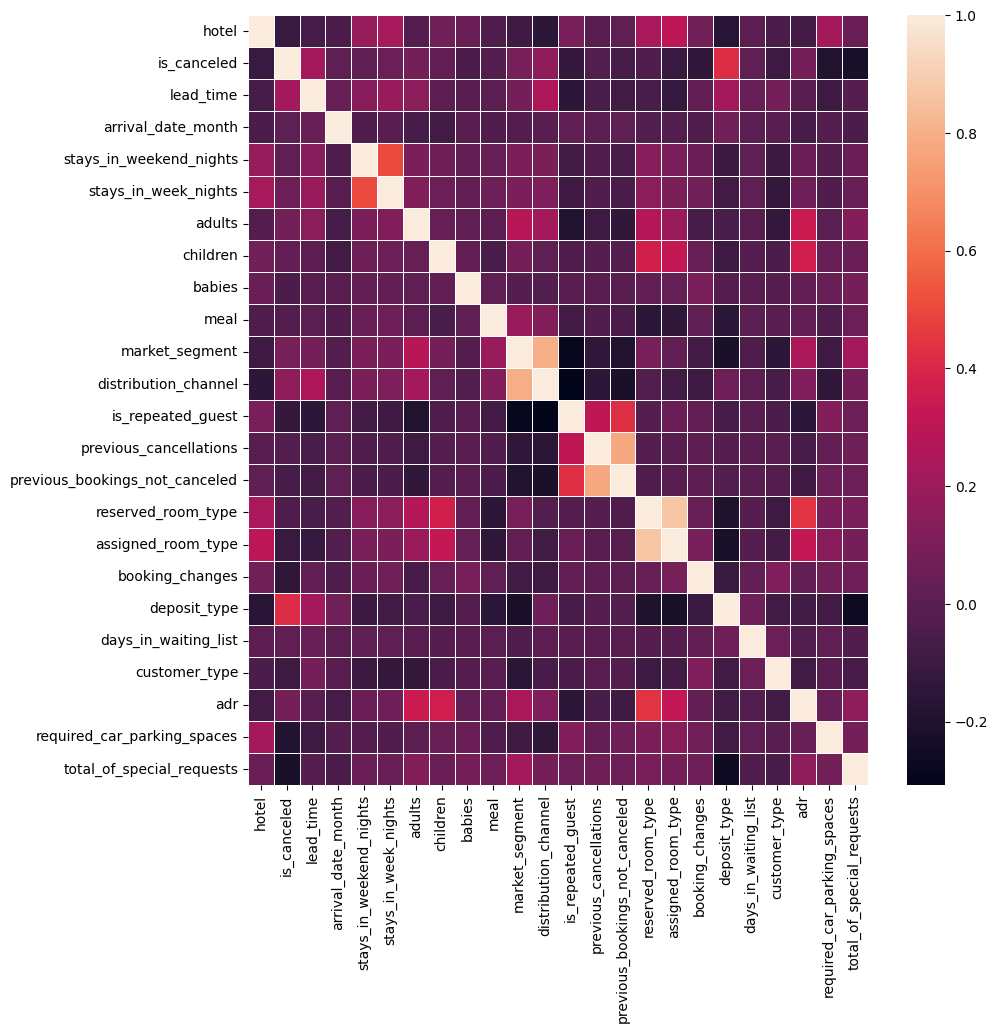

In [44]:
plt.figure(figsize=(10,10))
sns.heatmap(corr, linewidths=0.5)

In [48]:
# Skewness
skewness=df1.skew()
skewness

hotel                              0.758055
is_canceled                        0.469729
lead_time                          1.471375
arrival_date_month                -0.109305
stays_in_weekend_nights            1.377083
stays_in_week_nights               2.917604
adults                            -0.383273
children                           3.568237
babies                            12.489640
meal                               1.371510
market_segment                    -1.139137
distribution_channel              -1.942581
is_repeated_guest                  5.173326
previous_cancellations            15.599444
previous_bookings_not_canceled     7.673308
reserved_room_type                 1.181167
assigned_room_type                 1.073502
booking_changes                    2.493050
deposit_type                       2.703636
days_in_waiting_list              15.761921
customer_type                     -0.587857
adr                                0.933729
required_car_parking_spaces     

In [47]:
for col in df1.columns:
    if skewness[col]>5:
        df1[col]=np.log1p(df1[col])

In [49]:
df1.is_canceled.value_counts()

is_canceled
0    19996
1    12554
Name: count, dtype: int64

In [50]:
X=df1.drop(columns='is_canceled')
y=df1['is_canceled']

In [53]:
X.shape#23, 32550
y.shape#32550

(32550,)

In [54]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_res,y_res=smote.fit_resample(X,y)

In [55]:
X_res.shape

(39992, 23)

In [59]:
balanced_df=pd.DataFrame(X_res, columns=X.columns)
balanced_df['reservation_status']=y_res
balanced_df.shape
df1=balanced_df.copy()

In [60]:
df1.shape

(39992, 24)

In [61]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state=42)
model.fit(X,y)

RandomForestClassifier(random_state=42)

In [62]:
feature_importances=model.feature_importances_
fi_df=pd.DataFrame({
    'feature': X.columns,
    'importance':feature_importances
})

In [63]:
fi_df

,feature,importance
0,hotel,0.014132
1,lead_time,0.232793
2,arrival_date_month,0.060805
3,stays_in_weekend_nights,0.040710
4,stays_in_week_nights,0.067778
5,adults,0.021771
6,children,0.010610
7,babies,0.000880
8,meal,0.018611
9,market_segment,0.053453


In [64]:
top_features_df=fi_df.sort_values(by='importance', ascending=False)
top_features_df

,feature,importance
1,lead_time,0.232793
20,adr,0.153074
17,deposit_type,0.105396
4,stays_in_week_nights,0.067778
22,total_of_special_requests,0.065873
2,arrival_date_month,0.060805
9,market_segment,0.053453
3,stays_in_weekend_nights,0.040710
19,customer_type,0.034535
15,assigned_room_type,0.028706


In [122]:
len(df1.columns)

25

In [66]:
top_10_features=top_features_df['feature'].head(10).values
top_10_features

array(['lead_time', 'adr', 'deposit_type', 'stays_in_week_nights',
       'total_of_special_requests', 'arrival_date_month',
       'market_segment', 'stays_in_weekend_nights', 'customer_type',
       'assigned_room_type'], dtype=object)

In [69]:
df1.columns

Index(['hotel', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'market_segment', 'distribution_channel', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'reserved_room_type', 'assigned_room_type', 'booking_changes',
       'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status'],
      dtype='object')

In [71]:
top_10_df=df1[top_10_features.tolist() + ['reservation_status']]
top_10_df

,lead_time,adr,deposit_type,stays_in_week_nights,total_of_special_requests,arrival_date_month,market_segment,stays_in_weekend_nights,customer_type,assigned_room_type,reservation_status
0,64,189.000000,0,1,0,7,6,2,2,3,1
1,34,146.000000,0,1,0,4,3,1,2,0,0
2,251,89.700000,0,4,1,7,3,2,2,4,1
3,23,42.430000,0,1,1,2,6,1,2,3,0
4,123,105.300000,0,1,1,5,6,2,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...
39987,115,135.000000,0,3,0,7,6,0,2,3,1
39988,181,117.900000,0,2,0,4,6,1,2,3,1
39989,181,175.500000,0,2,0,2,6,0,2,3,1
39990,46,90.000000,0,1,0,5,4,0,3,0,1


In [72]:
top_10_df.shape
data_final=top_10_df.copy()
data_final.shape
X_new=data_final.drop(columns='reservation_status')
y_new=data_final['reservation_status']



In [74]:
y_new.shape

(39992,)

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score

In [76]:
X_train, X_test, y_train, y_test=train_test_split(X_new,y_new, test_size=0.3, random_state=42)


In [77]:
classifiers={
    'Random_Forest': RandomForestClassifier(random_state=42),
    'Gradient_Boosting': GradientBoostingClassifier(random_state=42),
    'Adaboost': AdaBoostClassifier(random_state=42),
    'Logistic_Regession': LogisticRegression(random_state=42),
    'SVC': SVC(random_state=42),
    'Decesion_Tree': DecisionTreeClassifier(random_state=42),
    'Gausian_NB': GaussianNB(),
    'K_Neighbors':KNeighborsClassifier(),
    'XGB_Classifier': XGBClassifier(),
    'LGBM_Classifier':LGBMClassifier(random_state=42)
}

In [78]:
matrics={"Model":[],
         "Accuracy":[],
         "Precesion_Score":[],
         "Recall_Score":[],
         "F1_Score":[]
}

In [84]:
X_test.shape

(11998, 10)

In [ ]:
model1=XGBClassifier()
model1.fit(X_train,y_train)
y_pred1=model1.predict(X_test)
acc=accuracy_score(y_test,y_pred1)
pre=precision_score(y_test,y_pred1)
rec=recall_score(y_test,y_pred1)
f11=f1_score(y_test,y_pred1)
print(acc,pre,rec,f11)
#DTree 0.7777962993832306 0.7725217952857604 0.7919563058589871 0.7821183393265773
#RF 0.8152192032005334 0.8230028711366323 0.8065210195299569 0.8146785923263395 
#RF_fineTuned 0.8114685780963494 0.8129139072847682 0.8126448195961602 0.8127793411686807
#GB 0.7588764794132355 0.7880007316627035 0.7130089374379345 0.7486315057780867
#LGBM 0.7840473412235373 0.8041600564075445 0.7550479973518702 0.7788305591122493
#XGBM 0.7911318553092183 0.7992552471225457 0.7815292949354519 0.7902928870292887

0.7911318553092183 0.7992552471225457 0.7815292949354519 0.7902928870292887


In [90]:
for model_name, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    matrics["Model"].append(model_name)
    matrics["Accuracy"].append(accuracy)
    matrics["Precesion_Score"].append(precision)
    matrics["Recall_Score"].append(recall)
    matrics["F1_Score"].append(f1)
    

[LightGBM] [Info] Number of positive: 13954, number of negative: 14040
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 583
[LightGBM] [Info] Number of data points in the train set: 27994, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498464 -> initscore=-0.006144
[LightGBM] [Info] Start training from score -0.006144


In [91]:
matrics

{'Model': ['Random_Forest',
  'Gradient_Boosting',
  'Adaboost',
  'Logistic_Regession',
  'SVC',
  'Decesion_Tree',
  'Gausian_NB',
  'K_Neighbors',
  'XGB_Classifier',
  'LGBM_Classifier'],
 'Accuracy': [0.8169694949158193,
  0.7588764794132355,
  0.7319553258876479,
  0.7212035339223204,
  0.6495249208201367,
  0.7783797299549925,
  0.6335222537089515,
  0.7405400900150025,
  0.7911318553092183,
  0.7840473412235373],
 'Precesion_Score': [0.8263747454175153,
  0.7880007316627035,
  0.7645076750280794,
  0.7319002579535684,
  0.621994952848984,
  0.7741935483870968,
  0.9981829194427619,
  0.7183539585507679,
  0.7992552471225457,
  0.8041600564075445],
 'Recall_Score': [0.8058589870903674,
  0.7130089374379345,
  0.6759351208209202,
  0.7044025157232704,
  0.7750744786494538,
  0.7904667328699106,
  0.27275736511089044,
  0.7974180734856008,
  0.7815292949354519,
  0.7550479973518702],
 'F1_Score': [0.8159879336349924,
  0.7486315057780867,
  0.7174982431482783,
  0.7178881673273172

In [92]:
results=pd.DataFrame(matrics)
results

,Model,Accuracy,Precesion_Score,Recall_Score,F1_Score
0,Random_Forest,0.816969,0.826375,0.805859,0.815988
1,Gradient_Boosting,0.758876,0.788001,0.713009,0.748632
2,Adaboost,0.731955,0.764508,0.675935,0.717498
3,Logistic_Regession,0.721204,0.731900,0.704403,0.717888
4,SVC,0.649525,0.621995,0.775074,0.690148
5,Decesion_Tree,0.778380,0.774194,0.790467,0.782246
6,Gausian_NB,0.633522,0.998183,0.272757,0.428441
7,K_Neighbors,0.740540,0.718354,0.797418,0.755824
8,XGB_Classifier,0.791132,0.799255,0.781529,0.790293
9,LGBM_Classifier,0.784047,0.804160,0.755048,0.778831


In [173]:
data_final.shape
X_new=data_final.drop(columns='reservation_status')
y_new=data_final['reservation_status']
X_train, X_test, y_train, y_test=train_test_split(X_new,y_new, test_size=0.3, random_state=42)
data_final.shape

(39992, 11)

In [174]:
data_final.isnull().sum()

is_canceled                    0
deposit_type                   0
lead_time                      0
total_of_special_requests      0
market_segment                 0
customer_type                  0
booking_changes                0
required_car_parking_spaces    0
adr                            0
distribution_channel           0
reservation_status             0
dtype: int64

In [93]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [188]:
model1=RandomForestClassifier(random_state=42)
#model1.fit(X_train,y_train)
#y_pred1=model1.predict(X_test)
#acc=accuracy_score(y_test,y_pred1)
#pre=precision_score(y_test,y_pred1)
#rec=recall_score(y_test,y_pred1)
#f11=f1_score(y_test,y_pred1)
#print(acc,pre,rec,f11)

In [100]:
param={
    'n_estimators': randint(100,500),
    'max_depth': randint(10,50),
    'min_samples_split':randint(2,10),
    'min_samples_leaf':randint(1,5),
    'bootstrap': [True, False]
    

}

In [101]:
random_search=RandomizedSearchCV(
    estimator=model1,
    param_distributions=param,
    n_iter=5,
    cv=5,
    scoring='accuracy',
    verbose=2,
    random_state=42

)

In [96]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=  11.0s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   9.6s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   9.4s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   9.7s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=  11.6s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=  16.2s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=  12.8s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=  10.8s
[CV]

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024D0F14E2C0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024D0F14C430>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024D0F262CB0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024D0F2619C0>},
                   random_state=42, scoring='accuracy', verbose=2)

In [97]:
rf_best_params=random_search.best_params_
rf_best_params

{'bootstrap': False,
 'max_depth': 33,
 'min_samples_leaf': 4,
 'min_samples_split': 7,
 'n_estimators': 393}

In [98]:
best_model=random_search.best_estimator_

In [102]:
ypred_best_model=best_model.predict(X_test)
acc=accuracy_score(y_test,ypred_best_model)
pre=precision_score(y_test,ypred_best_model)
rec=recall_score(y_test,ypred_best_model)
f11=f1_score(y_test,ypred_best_model)
print(acc,pre,rec,f11)

0.8114685780963494 0.8129139072847682 0.8126448195961602 0.8127793411686807


In [105]:
import joblib

joblib.dump(ypred_best_model, 'rf_best_model.pkl')

['rf_best_model.pkl']

In [106]:
loaded_model=joblib.load('rf_best_model.pkl')
loaded_model=best_model.predict(X_test)
acc=accuracy_score(y_test,ypred_best_model)
pre=precision_score(y_test,ypred_best_model)
rec=recall_score(y_test,ypred_best_model)
f11=f1_score(y_test,ypred_best_model)
print(acc,pre,rec,f11)

0.8114685780963494 0.8129139072847682 0.8126448195961602 0.8127793411686807
